# SWH correction

In [1]:
import glob
import os
import warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe

# ── Dask ─────────────────────────────────────────────────────────────────────
import dask
import dask.bag as db
from dask.distributed import Client, LocalCluster, progress, wait

from swot_analysis import compute_pass_spectra
#from swot_analysis import load_swot_l2_expert 

In [2]:
DATA_DIR = '/Users/zoecas/Documents/data/'
DATA_SUBDIR = 'SWOT_L2_LR_SSH_Expert_0225'
FILE_PATTERN = 'SWOT_L2_LR_SSH_Expert_027*.nc'

N_WORKERS = 4
THREADS_PER_WORKER = 1
MEMORY_LIMIT       = '4GB'   # per worker RAM cap
HRET = True

In [3]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_PER_WORKER,
    memory_limit=MEMORY_LIMIT,
    dashboard_address=':8787',
)
client = Client(cluster)
print(f"Dashboard: {client.dashboard_link}")
client   # displays the interactive widget in JupyterLab

Dashboard: http://127.0.0.1:8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 4
Total threads: 4,Total memory: 14.90 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:64951,Workers: 0
Dashboard: http://127.0.0.1:8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:64962,Total threads: 1
Dashboard: http://127.0.0.1:64966/status,Memory: 3.73 GiB
Nanny: tcp://127.0.0.1:64954,


In [4]:
def load_swot_l2_expert(filepath : str, ssh_var : str='ssha_karin_2', HRET : bool=True, other_var=None):
    # NO type annotations — avoids Python 3.14 PEP 649 __annotate__ capture bug
    ds = xr.open_dataset(filepath)
    if HRET:
        ssha = (ds[ssh_var] + ds['height_cor_xover'] + ds['internal_tide_hret']).values
    else:
        ssha   = np.array(ds[ssh_var] + ds['height_cor_xover'], dtype='float64')
        
    for qual_name in (f'{ssh_var}_qual', 'ssha_karin_qual', 'ssh_karin_2_qual'):
        if qual_name in ds.variables:
            ssha = np.where(np.array(ds[qual_name]) == 0, ssha, np.nan)
            #ssha = np.where(ds[qual_name].values == 0, ssha, np.nan)
            break
    for scf in ('ancillary_surface_classification_flag', 'surface_classification_flag'):
        if scf in ds.variables:
            ssha = np.where(np.array(ds[scf]) == 0, ssha, np.nan)
            break
            
    if 'surface_type' in ds.variables:
        ssha = np.where(np.array(ds['surface_type']) == 0, ssha, np.nan)
        
    
    lat = ds['latitude'].values
    lon = ds['longitude'].values
    xtrack = np.array(ds['cross_track_distance'], dtype='float64')
    xtrack = ds['cross_track_distance'].values
    
    ds.close()
    if other_var:
        dict_others = {other_name : ds[other_name].values for other_name in other_var}
        dict_out = {'ssha': ssha, 'latitude': lat, 'longitude': lon,'cross_track_distance': xtrack}
        dict_out.update(dict_others)
        return dict_out
    else:
        return {'ssha': ssha, 'latitude': lat, 'longitude': lon,'cross_track_distance': xtrack}

In [5]:
filepaths = []
subdir_files = sorted(glob.glob(os.path.join(DATA_DIR, DATA_SUBDIR, FILE_PATTERN)))
filepaths.extend(subdir_files)

print(f'\n{len(filepaths)} Expert granule files found')



73 Expert granule files found


In [6]:

import functools

worker_fn = functools.partial(
    load_swot_l2_expert,
    ssh_var='ssha_karin_2', HRET=True, other_var=['swh_karin','swh_karin_qual']
)

futures = client.map(worker_fn, filepaths)



# Live progress bar inside the notebook (also visible on the Dashboard)
progress(futures)

# Block until all futures are complete
wait(futures)
#load_swot_l2_expert()

DoneAndNotDoneFutures(done={<Future: finished, type: dict, key: load_swot_l2_expert-6159b9eb3ca4b3431e76394888d4477a>, <Future: finished, type: dict, key: load_swot_l2_expert-57d731c07e85bccfabf5449469b761f9>, <Future: finished, type: dict, key: load_swot_l2_expert-ee9fd62e4f72a1db6708ec94ca488bfd>, <Future: finished, type: dict, key: load_swot_l2_expert-f7e3f4525fe3d7d52899100f6332b38d>, <Future: finished, type: dict, key: load_swot_l2_expert-fbbb712c1e9a6bf3bde97689fad3d3af>, <Future: finished, type: dict, key: load_swot_l2_expert-19f16deb5bea8a871bf4c2ae11059920>, <Future: finished, type: dict, key: load_swot_l2_expert-595cc658946508dc94d699acc9be0fea>, <Future: finished, type: dict, key: load_swot_l2_expert-07adea6ff14be333bcf229f730a86af3>, <Future: finished, type: dict, key: load_swot_l2_expert-0b4c291eecda6a1374dd98631702bed1>, <Future: finished, type: dict, key: load_swot_l2_expert-95586b641cec8d734d4cdf1f0c91560a>, <Future: finished, type: dict, key: load_swot_l2_expert-1e9b6d

In [7]:
# Gather results back to the main process
raw_results = client.gather(futures)


KeyboardInterrupt

Exception ignored on calling weakref callback <function WeakKeyDictionary.__init__.<locals>.remove at 0x142ad1380>:
Traceback (most recent call last):
  File "/Users/zoecas/miniconda3/envs/croco/lib/python3.14/weakref.py", line 311, in remove
    def remove(k, selfref=ref(self)):
KeyboardInterrupt: 
Exception ignored while calling GC callback <bound method GCDiagnosis._gc_callback of <distributed.gc.GCDiagnosis object at 0x1328738c0>>:
Traceback (most recent call last):
  File "/Users/zoecas/miniconda3/envs/croco/lib/python3.14/site-packages/distributed/gc.py", line 199, in _gc_callback
    def _gc_callback(self, phase, info):
KeyboardInterrupt: 


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x130f82e50> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

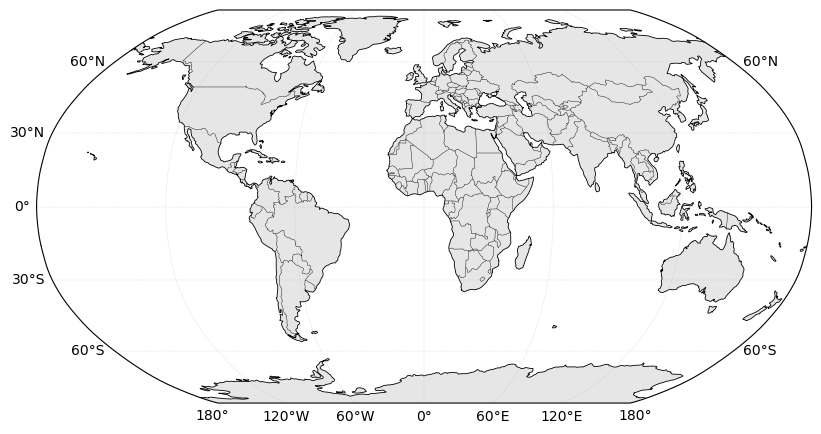

In [18]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
figsize = (10,7)
projection = ccrs.Robinson()
fig = plt.figure(figsize=figsize)
ax = plt.axes(projection=projection)
ax.set_global()
ax.add_feature(cfeature.LAND,facecolor="0.9",edgecolor="none")
ax.add_feature(cfeature.COASTLINE,linewidth=0.6)
ax.add_feature(cfeature.BORDERS,linewidth=0.3)
gl = ax.gridlines(draw_labels=True,linewidth=0.3,linestyle="--",alpha=0.5)
    
gl.top_labels = False
gl.right_labels = False

gl.xlocator = mticker.FixedLocator(np.arange(-180, 181, 60))
gl.ylocator = mticker.FixedLocator(np.arange(-60, 61, 30))

gl.xlabel_style = {"size": 10,"color": "black",}

gl.ylabel_style = {"size": 10,"color": "black",}
for r in raw_results:
    ax.pcolormesh(r['longitude'],r['latitude'],r['ssha'])
#raw_results

In [11]:
# Shut down the cluster when done.
client.close()
cluster.close()


/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_2884/3798524115.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['ssha'])


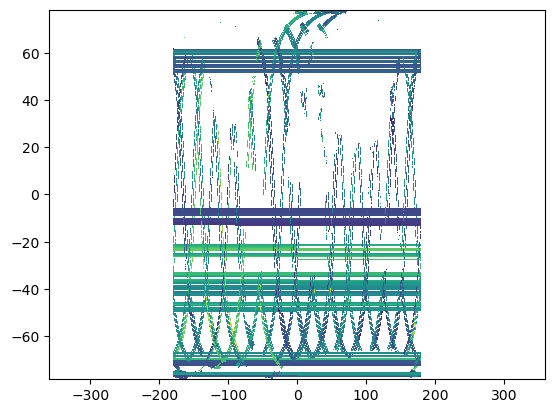

In [22]:
for r in raw_results:
    plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['ssha'])

/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_3485/2994247038.py:2: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['ssha'],vmax=0.3)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_3485/2994247038.py:6: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  cs = plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['swh_karin'],vmax=6)
/var/folders/fv/pmf052vs1g77j8b23nzvlkmm0000gr/T/ipykernel_3485/2994247038.py:10: UserWarning: The input coordinates to pcolormesh are interpreted as cell center

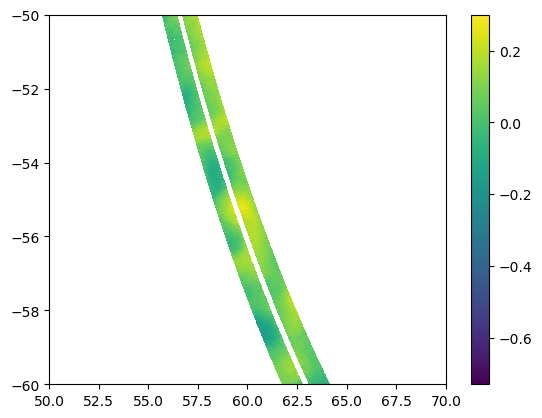

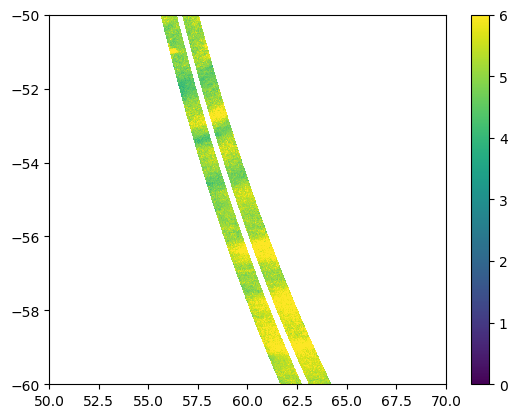

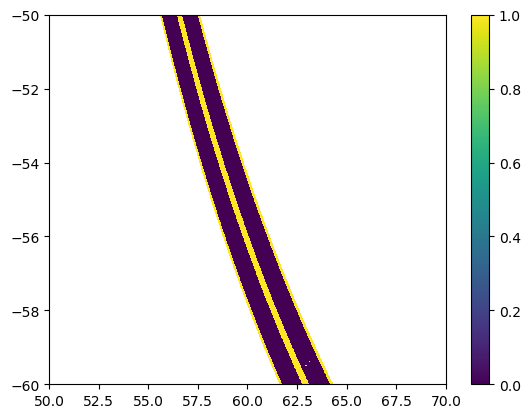

In [10]:
r = raw_results[0]
cs = plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['ssha'],vmax=0.3)
plt.xlim(50,70);plt.ylim(-60,-50)
plt.colorbar(cs)
plt.figure()
cs = plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['swh_karin'],vmax=6)
plt.xlim(50,70);plt.ylim(-60,-50)
plt.colorbar(cs)
plt.figure()
cs = plt.pcolormesh(((r['longitude']+180)%360)-180,r['latitude'],r['swh_karin_qual'],vmax=1)
plt.xlim(50,70);plt.ylim(-60,-50)
plt.colorbar(cs)